# Building Explainable Machine Learning Models
 Partial Dependence Plot(PDP) & Individual Conditional Expectation(ICE) Plots





Feature Importance gives us the features that affect the predicions, the partial dependence plots on the other hand, tell us how a feature affects the predictions. PDPs can analyze the interaction between the target and the input feature of interest, while marginalizing all the other input features [1]. In other words. what happens to the target when one of the feature changes but all other variables are held constant.


<div class="alert alert-block alert-info">

* [1]PDPs were introduced in the context of gradient boosting machines (GBM) by Friedman (2000)- Friedman, Jerome H. [“Greedy Function Approximation: A Gradient Boosting Machine.”](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boostingmachine/10.1214/aos/1013203451.full) Annals of Statistics 29: 1189–1232.
    
* Partial Dependence is calculated after a model has been fitted. So, let’s train and fit a Random Forest Classifier model on the training data.
    
* Also make sure that the model has a good predictive performance or in other words you have trained a good model before inspecting the importance of its features. There is no point in investigating a bad model.
    </div>



  Throghout this notebook, we are going to be working with the Partial Dependence Plots(PDPs) on a preprocessed version of the [Adult Income Dataset ](https://archive.ics.uci.edu/ml/datasets/adult) using scikit-learn. You'll perform the following steps:

1. Import and preprocess the dataset
2. Train a Random Forest classifier on the data.
3. Compute and plot one and two dimensional PDPs.
4. Explain the results


Let's get started!

---

## Case Study

### Predicting if income exceeds $50,000 per year based on 1994 US Census Data

 The Adult Income dataset, also known as the "Census Income" dataset, contains a variety of attributes or features that describe individuals in the dataset. The target variable is True if a person earns more than `$50K` annually and False if the earned income is ≤ $50K. The attributes of our dataset (preprocessed version) include:

* **Age** : the age of the individual
* **Workclass** : the type of employment the individual has (e.g. private, government, self-employed)
* **Education** : the level of education the individual has achieved (e.g. high school, college, graduate degree)
* **Marital-status** : the individual's marital status (e.g. married, divorced, single)
* **Occupation** : the type of work the individual is employed in (e.g. sales, management, craft-repair)
* **Race** : the individual's race (e.g. White, Black, Asian)
* **Sex** : the individual's gender (e.g. Male, Female)
* **Hours-per-week** : the number of hours the individual works per week
* **Income** : the individual's income level (either <=50K or >50K)


<div class="alert alert-block alert-danger">


Note that the attributes might be different based on the source of the dataset and the version you are using. Also this dataset reflects bias and imbalance w.r.t gender and race. Be careful when using such datasets. In this notebook this dataset is only used for demo purposes.

## Importing Necessary Libraries

Let’s start by importing the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

np.random.seed(123) #ensure reproducibility

import warnings
warnings.filterwarnings("ignore")

In [2]:
# setting up the styling for the plots in this notebook
sns.set(style="white", palette="colorblind", font_scale=0.8,
        rc={"figure.figsize":(10,8)})

##  Reading in the Dataset

Let’s read in the data and look at the first few rows



In [3]:
data= pd.read_csv(r'C:\Users\User\Desktop\Data-Science-Class\Data\Adult Income Dataset.csv')
data.head()

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,28,Private,Bachelors,Single,White-Collar,White,Female,60,0
1,30,Self-Employed,Assoc,Married,Professional,White,Male,65,1
2,32,Private,Some-college,Married,White-Collar,White,Male,50,0
3,20,Private,Some-college,Single,Service,White,Female,35,0
4,41,Self-Employed,Some-college,Married,White-Collar,White,Male,50,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26048 entries, 0 to 26047
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             26048 non-null  int64
 1   workclass       26048 non-null  str  
 2   education       26048 non-null  str  
 3   marital_status  26048 non-null  str  
 4   occupation      26048 non-null  str  
 5   race            26048 non-null  str  
 6   gender          26048 non-null  str  
 7   hours_per_week  26048 non-null  int64
 8   income          26048 non-null  int64
dtypes: int64(3), str(6)
memory usage: 1.8 MB


There are no missing values and no string columns in the given dataset.

In [5]:
# Inspecting Distribution of Target Variable

data['income'].value_counts()

income
0    19820
1     6228
Name: count, dtype: int64



## Data Preparation







### Train/Test Split
Splitting the dataset into traininga and validation dataset.

In [6]:
# Creating the target and the features column and splitting the dataset into test and train set.

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# splitting the dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)



## Encoding the categorical features

We'll leave the numerical features as-is and only encode the categorical features using a OrdinalEncoder.

In [7]:
numerical_features = [
    "age",
    "hours_per_week",
]
categorical_features = X_train.columns.drop(numerical_features)

In [8]:
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation', 'race',
       'gender'],
      dtype='str')

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_features),
        ("num", "passthrough", numerical_features),
    ],
    sparse_threshold=1,
    verbose_feature_names_out=False,
).set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",1
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The o

## Training the classifier

Now you will fit a [Random Forest classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and compute the [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html) achieved:

In [10]:
# Training and fitting a Random Forest Model

model = make_pipeline(
    preprocessor,
    RandomForestClassifier(n_estimators=100,max_depth=5,random_state=0)
)
model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','workclass','education',...,'race','gender','hours_per_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the

In [11]:
model.score(X_test, y_test)

0.8057432432432432

We now have our model and our predictions. Let’s now explore the different ways by which we can understand the model and its predictions in a more meaningful way.

---

## Calculating Partial Dependence plots

Partial Dependence plots are calculated as follows:

* Train a model
* Set all the values for the `feature of interest` to a particluar value without touching any other variables.
* Make predictions on the modified dataset using the previously trained model
* Average over all the predictions.
* Repeat for all the different values of the `feature of interest`.



The `sklearn.inspection` module provides a convenience function `plot_partial_dependence` to create one-way and two-way partial dependence plots.


## Plotting 1D PDPs

ValueError: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical features to floating point dtypes ahead of time to avoid problems.

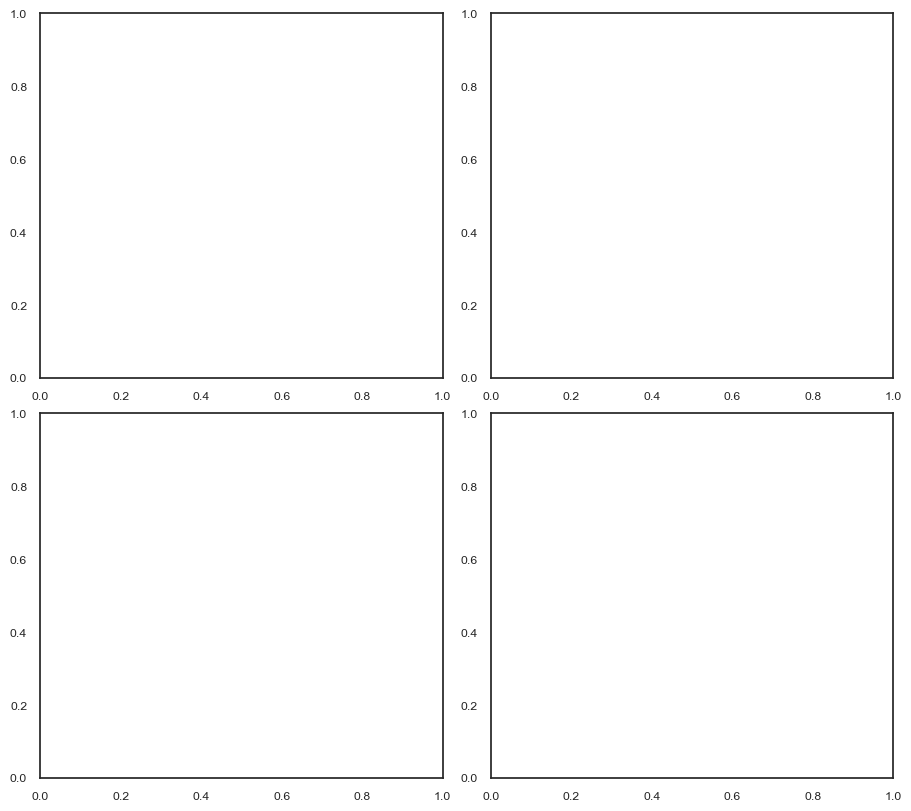

In [20]:
from sklearn.inspection import PartialDependenceDisplay
common_params = {
    "subsample": 50,
    "grid_resolution": 10,
    "random_state": 0,
}


features_info = {
    # features of interest
    "features": ["age", "hours_per_week", "workclass", "education"],
    # type of partial dependence plot
    "kind": "average",
    # information regarding categorical features
    "categorical_features":categorical_features,
}

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(9, 8), constrained_layout=True)

display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    **features_info,
    ax=ax.flatten(),
    **common_params,
)

display.figure_.suptitle(
    "Partial dependence plots",
    fontsize=16,
)

## ICE Plots

Partial dependence plots show the average effect of the features of interest while [Individual Conditional Expectation](https://arxiv.org/abs/1309.6392) plots visualize the dependence of the prediction on a feature for each sample separately, with one line per sample.

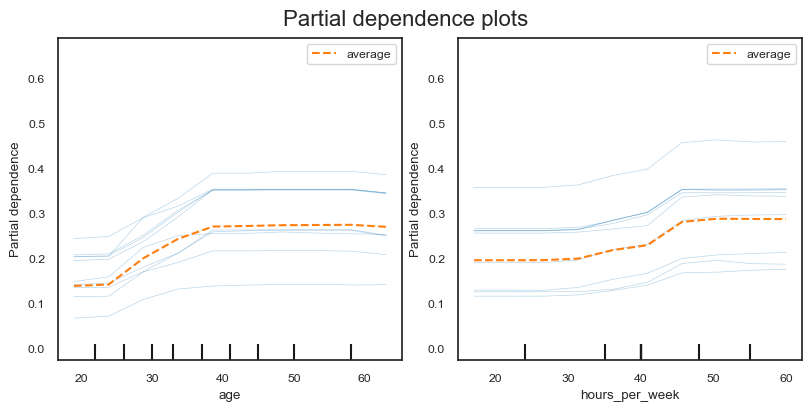

In [ ]:
common_params = {
    "subsample": 10,
    "grid_resolution": 10,
    "random_state": 0,
}


features_info = {
    # features of interest
    "features": ["age", "hours_per_week"],
    # type of partial dependence plot
    "kind": "both",
}

_, ax = plt.subplots(ncols=2, nrows=1, figsize=(8, 4), constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    **features_info,
    ax=ax,
    **common_params,
)

_ = display.figure_.suptitle(
    "Partial dependence plots",
    fontsize=16,
)

### References

[1] https://scikit-learn.org/stable/modules/partial_dependence.html

[2] T. Hastie, R. Tibshirani and J. Friedman, [The Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn), Second Edition, Section 10.13.2, Springer, 2009.

[3] C. Molnar, [Interpretable Machine Learning](https://christophm.github.io/interpretable-ml-book), Section 5.1, 2019.

[4] A. Goldstein, A. Kapelner, J. Bleich, and E. Pitkin, [Peeking Inside the Black Box: Visualizing Statistical Learning With Plots of Individual Conditional Expectation](https://arxiv.org/abs/1309.6392), Journal of Computational and Graphical Statistics, 24(1): 44-65, Springer, 2015.

---